In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import os

# ✅ Fixed seed
torch.manual_seed(42)
np.random.seed(42)

mlflow.set_experiment("ecg-ssl-finetuning")


2026/05/18 08:35:13 INFO mlflow.tracking.fluent: Experiment with name 'ecg-ssl-finetuning' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Applications/AI/ecg-ssl-research-final/mlruns/2', creation_time=1779073513622, experiment_id='2', last_update_time=1779073513622, lifecycle_stage='active', name='ecg-ssl-finetuning', tags={}, trace_location=None, workspace='default'>

In [2]:
FINE_TUNE_RUN_NAME = "ssl-finetune-fulldata"

if mlflow.active_run() is not None:
    mlflow.end_run()

mlflow.start_run(run_name=FINE_TUNE_RUN_NAME)
print(f"MLflow run started: {mlflow.active_run().info.run_id}")


MLflow run started: 5bd80865c14946cf961cb07b5c112764


In [3]:
# ✅ Load the pre-split, already-normalized data from Preprocessing
X_train = np.load("./ecg_ssl_research/data/processed/X_train.npy")
X_val   = np.load("./ecg_ssl_research/data/processed/X_val.npy")
X_test  = np.load("./ecg_ssl_research/data/processed/X_test.npy")
y_train = np.load("./ecg_ssl_research/data/processed/y_train.npy")
y_val   = np.load("./ecg_ssl_research/data/processed/y_val.npy")
y_test  = np.load("./ecg_ssl_research/data/processed/y_test.npy")

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape},   {y_val.shape}")
print(f"Test:  {X_test.shape},  {y_test.shape}")

Train: (54212, 180), (54212,)
Val:   (13554, 180),   (13554,)
Test:  (16942, 180),  (16942,)


In [4]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights)

Class weights: tensor([ 0.3763, 11.0863,  3.9611])


In [5]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
train_dataset = ECGDataset(X_train, y_train)
val_dataset   = ECGDataset(X_val,   y_val)
test_dataset  = ECGDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 848
Val   batches: 212
Test  batches: 265


In [7]:
class ECGClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        # ✅ Same architecture as ECGAutoencoder encoder
        # including BatchNorm added in Pretraining notebook
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        # ✅ Load pretrained weights
        self.encoder.load_state_dict(
            torch.load("./models/pretrained_encoder.pth",
                       weights_only=True)
        )
        print("✅ Pretrained encoder loaded!")

        self.pool = nn.AdaptiveAvgPool1d(1)

        # ✅ Strong classifier head
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECGClassifier().to(device)

# ✅ Encoder unfrozen — full fine-tuning
for param in model.encoder.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ✅ ReduceLROnPlateau on val loss
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print(f"Training on: {device}")
print(f"Total params:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

✅ Pretrained encoder loaded!
Training on: cpu
Total params:     46,275
Trainable params: 46,275


In [9]:
epochs        = 40
best_val_loss = float('inf')
patience      = 10
counter       = 0

mlflow.log_params({
    "pretrained": True,
    "encoder_frozen": False,
    "classifier_layers": "128->64->32->3",
    "dropout": 0.3,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": epochs,
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    "patience": patience,
    "architecture": "Conv1D-Classifier",
    "dataset": "MIT-BIH",
    "class_weights": "balanced",
    "n_train_samples": len(X_train),
    "n_val_samples": len(X_val),
    "n_test_samples": len(X_test)
})

for epoch in range(epochs):

    # ========================
    # TRAINING PHASE
    # ========================
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ========================
    # VALIDATION PHASE
    # ========================
    model.eval()
    val_loss  = 0
    all_preds = []
    all_true  = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    # ========================
    # METRICS
    # ========================
    report_dict = classification_report(all_true, all_preds, output_dict=True)
    recall_N   = report_dict['0']['recall']
    recall_A   = report_dict['1']['recall']
    recall_V   = report_dict['2']['recall']
    accuracy   = report_dict['accuracy']
    macro_f1   = report_dict['macro avg']['f1-score']
    current_lr = optimizer.param_groups[0]['lr']

    mlflow.log_metrics({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "accuracy": accuracy,
        "recall_N": recall_N,
        "recall_A": recall_A,
        "recall_V": recall_V,
        "macro_f1": macro_f1,
        "lr": current_lr
    }, step=epoch + 1)

    print(f"Epoch {epoch+1:>3} | "
          f"Train: {avg_train_loss:.4f} | "
          f"Val: {avg_val_loss:.4f} | "
          f"Acc: {accuracy:.4f} | "
          f"Recall A: {recall_A:.4f} | "
          f"Recall V: {recall_V:.4f} | "
          f"Macro F1: {macro_f1:.4f} | "
          f"LR: {current_lr:.2e}")

    # ✅ Step on val loss
    scheduler.step(avg_val_loss)

    # ========================
    # EARLY STOPPING
    # ========================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        os.makedirs("./models", exist_ok=True)
        torch.save(model.state_dict(), "./models/best_finetuned_model.pth")
        print("  ✅ Val loss improved → model saved")
    else:
        counter += 1
        print(f"  ⚠️  No improvement for {counter}/{patience} epochs")
        if counter >= patience:
            print("  🛑 Early stopping triggered!")
            break


Epoch   1 | Train: 0.3176 | Val: 0.2359 | Acc: 0.9224 | Recall A: 0.8403 | Recall V: 0.9781 | Macro F1: 0.7691 | LR: 1.00e-03
  ✅ Val loss improved → model saved
Epoch   2 | Train: 0.2100 | Val: 0.1711 | Acc: 0.9545 | Recall A: 0.9017 | Recall V: 0.9676 | Macro F1: 0.8387 | LR: 1.00e-03
  ✅ Val loss improved → model saved
Epoch   3 | Train: 0.1750 | Val: 0.1798 | Acc: 0.9397 | Recall A: 0.8894 | Recall V: 0.9860 | Macro F1: 0.8085 | LR: 1.00e-03
  ⚠️  No improvement for 1/10 epochs
Epoch   4 | Train: 0.1556 | Val: 0.1428 | Acc: 0.9379 | Recall A: 0.9189 | Recall V: 0.9877 | Macro F1: 0.8063 | LR: 1.00e-03
  ✅ Val loss improved → model saved
Epoch   5 | Train: 0.1398 | Val: 0.1469 | Acc: 0.9337 | Recall A: 0.9189 | Recall V: 0.9746 | Macro F1: 0.8006 | LR: 1.00e-03
  ⚠️  No improvement for 1/10 epochs
Epoch   6 | Train: 0.1252 | Val: 0.1304 | Acc: 0.9627 | Recall A: 0.9189 | Recall V: 0.9755 | Macro F1: 0.8612 | LR: 1.00e-03
  ✅ Val loss improved → model saved
Epoch   7 | Train: 0.1313 

=== Confusion Matrix ===
[[14745   204    58]
 [   42   466     1]
 [   15     8  1403]]

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     15007
    Afib (A)       0.69      0.92      0.79       509
   VTach (V)       0.96      0.98      0.97      1426

    accuracy                           0.98     16942
   macro avg       0.88      0.96      0.92     16942
weighted avg       0.98      0.98      0.98     16942



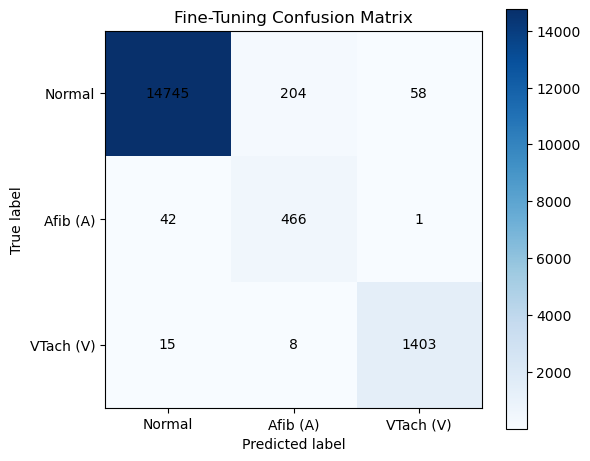

2026/05/18 09:04:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 09:04:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Run ID: 5bd80865c14946cf961cb07b5c112764


Successfully registered model 'ECG-Arrhythmia-Classifier'.
Created version '1' of model 'ECG-Arrhythmia-Classifier'.


In [10]:
# ✅ Load best saved model
# ✅ Evaluate ONLY on test set — these numbers were never seen during training
model.load_state_dict(
    torch.load("./models/best_finetuned_model.pth",
               map_location=device, weights_only=True)
)
model.eval()

all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)
report_text = classification_report(
    all_true, all_preds,
    target_names=["Normal", "Afib (A)", "VTach (V)"]
)
report_dict = classification_report(
    all_true, all_preds,
    target_names=["Normal", "Afib (A)", "VTach (V)"],
    output_dict=True
)

print("=== Confusion Matrix ===")
print(cm)
print()
print("=== Classification Report ===")
print(report_text)

artifact_dir = "./mlflow_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=range(3),
    yticks=range(3),
    xticklabels=["Normal", "Afib (A)", "VTach (V)"],
    yticklabels=["Normal", "Afib (A)", "VTach (V)"],
    xlabel="Predicted label",
    ylabel="True label",
    title="Fine-Tuning Confusion Matrix"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

fig.tight_layout()
confusion_matrix_path = os.path.join(artifact_dir, "finetuning_confusion_matrix.png")
fig.savefig(confusion_matrix_path, bbox_inches="tight")
mlflow.log_artifact(confusion_matrix_path)
plt.show()

classification_report_path = os.path.join(artifact_dir, "finetuning_classification_report.txt")
with open(classification_report_path, "w") as f:
    f.write(report_text)
mlflow.log_artifact(classification_report_path)

mlflow.log_metrics({
    "test_accuracy": report_dict["accuracy"],
    "test_recall_N": report_dict["Normal"]["recall"],
    "test_recall_A": report_dict["Afib (A)"]["recall"],
    "test_recall_V": report_dict["VTach (V)"]["recall"],
    "test_macro_f1": report_dict["macro avg"]["f1-score"]
})

try:
    mlflow.pytorch.log_model(
        model,
        artifact_path="ecg_classifier",
        registered_model_name="ECG-Arrhythmia-Classifier"
    )
except Exception as exc:
    print(f"Model registry unavailable ({exc}). Logging classifier without registration.")
    mlflow.pytorch.log_model(model, artifact_path="ecg_classifier")

print(f"Run ID: {mlflow.active_run().info.run_id}")


In [11]:
if mlflow.active_run() is not None:
    mlflow.end_run()
    print("MLflow run closed.")


MLflow run closed.
